[INFO] Total patches: 2688
[INFO] Total patches: 684
Epoch 1/20 | Loss: 0.5096 | F1: 0.9007 | Acc: 0.8904
✅ Saved Best Model
Epoch 2/20 | Loss: 0.4941 | F1: 0.8333 | Acc: 0.8333
Epoch 3/20 | Loss: 0.4804 | F1: 0.8699 | Acc: 0.8640
Epoch 4/20 | Loss: 0.4791 | F1: 0.8871 | Acc: 0.8801
Epoch 5/20 | Loss: 0.4644 | F1: 0.8991 | Acc: 0.8904
Epoch 6/20 | Loss: 0.4446 | F1: 0.8273 | Acc: 0.8333
Epoch 7/20 | Loss: 0.4494 | F1: 0.9111 | Acc: 0.9050
✅ Saved Best Model
Epoch 8/20 | Loss: 0.4280 | F1: 0.8670 | Acc: 0.8699
Epoch 9/20 | Loss: 0.4207 | F1: 0.9096 | Acc: 0.9006
Epoch 10/20 | Loss: 0.4170 | F1: 0.9126 | Acc: 0.9079
✅ Saved Best Model
Epoch 11/20 | Loss: 0.3809 | F1: 0.9224 | Acc: 0.9196
✅ Saved Best Model
Epoch 12/20 | Loss: 0.3978 | F1: 0.8819 | Acc: 0.8845
Epoch 13/20 | Loss: 0.4075 | F1: 0.9258 | Acc: 0.9211
✅ Saved Best Model
Epoch 14/20 | Loss: 0.3995 | F1: 0.9091 | Acc: 0.9079
Epoch 15/20 | Loss: 0.3691 | F1: 0.9072 | Acc: 0.9064
Epoch 16/20 | Loss: 0.3871 | F1: 0.9243 | Acc: 0.91

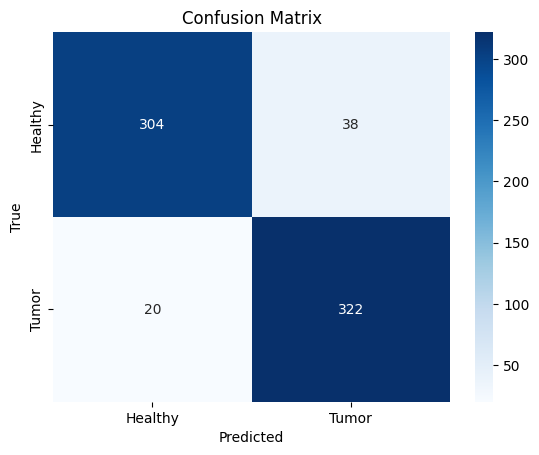

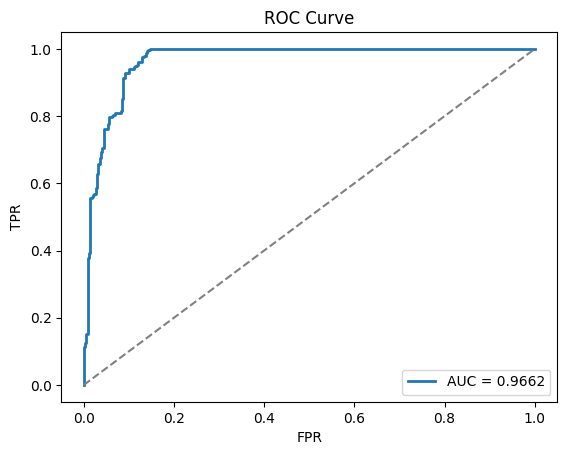

In [4]:
# ================= INSTALL =================
!pip install monai timm -q

# ================= IMPORTS =================
import os
import warnings
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from monai.networks.nets.swin_unetr import SwinTransformer as MonaiSwinTransformer

# ================= CONFIG =================
PATCH_SIZE = 96
BATCH_SIZE = 2
EPOCHS = 20
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR  = os.path.join(BASE_PATH, "labelsTr")

# ================= DATASET =================
class Pancreas3DPatchDataset(Dataset):
    def __init__(self, files, patch_size=PATCH_SIZE, augment=False):
        self.files = files
        self.patch_size = patch_size
        self.augment = augment
        self.samples = self._prepare_samples()
        if len(self.samples) == 0:
            raise ValueError("No valid patches found!")

    def _prepare_samples(self):
        samples = []
        p = self.patch_size
        for f in self.files:
            # skip hidden or invalid files
            if f.startswith(".") or f.startswith("._"):
                continue

            mask_path = os.path.join(MASK_DIR, f)
            if not os.path.exists(mask_path):
                continue

            mask_vol = nib.load(mask_path).get_fdata()

            tumor_idx = np.argwhere(mask_vol == 2)
            healthy_idx = np.argwhere(mask_vol == 0)

            if len(tumor_idx) == 0 or len(healthy_idx) == 0:
                continue

            # --- tumor patches
            for _ in range(6):
                idx = tumor_idx[np.random.randint(len(tumor_idx))]
                samples.append((f, idx.tolist(), 1))

            # --- healthy/background patches
            for _ in range(6):
                idx = healthy_idx[np.random.randint(len(healthy_idx))]
                samples.append((f, idx.tolist(), 0))

        print(f"[INFO] Total patches: {len(samples)}")
        return samples

    def _normalize(self, patch):
        patch = np.clip(patch, -100, 400)
        return (patch + 100) / 500.0

    def _augment(self, patch):
        # random flip on each axis
        for ax in range(3):
            if np.random.rand() > 0.5:
                patch = np.flip(patch, axis=ax).copy()
        # random intensity shift
        patch += np.random.uniform(-0.05, 0.05)
        return np.clip(patch, 0, 1)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        f, center, label = self.samples[idx]
        img_vol = nib.load(os.path.join(IMAGE_DIR, f)).get_fdata()
        z, y, x = [int(c) for c in center]
        p = self.patch_size

        z_s = max(0, z - p//2)
        y_s = max(0, y - p//2)
        x_s = max(0, x - p//2)
        patch = img_vol[z_s:z_s+p, y_s:y_s+p, x_s:x_s+p]

        if patch.shape != (p, p, p):
            patch = np.pad(patch,
                           [(0, p - patch.shape[0]),
                            (0, p - patch.shape[1]),
                            (0, p - patch.shape[2])],
                           mode='constant')

        patch = self._normalize(patch)
        if self.augment:
            patch = self._augment(patch)

        return torch.tensor(patch[np.newaxis], dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# ================= DATA LOADERS =================
all_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith((".nii", ".nii.gz"))])
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = Pancreas3DPatchDataset(train_files, augment=True)
val_dataset   = Pancreas3DPatchDataset(val_files, augment=False)

# Weighted sampler for class imbalance
labels = [s[2] for s in train_dataset.samples]
counts = np.bincount(labels)
weights = 1.0 / counts[labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=2)

# ================= MODEL =================
class Swin3DClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = MonaiSwinTransformer(
            in_chans=1,
            embed_dim=48,
            window_size=(7,7,7),
            patch_size=(4,4,4),
            depths=(2,2,6,2),
            num_heads=(3,6,12,24),
            spatial_dims=3
        )
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.backbone(x)[-1]
        x = self.pool(x)
        return self.head(x)

# ================= TRAINING SETUP =================
model = Swin3DClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# ================= TRAINING LOOP =================
best_f1 = 0
val_accs, val_f1s = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = model(imgs)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    preds, gts, probs = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            probs.extend(F.softmax(out, dim=1)[:,1].cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(labels.cpu().numpy())

    f1 = f1_score(gts, preds)
    acc = accuracy_score(gts, preds)
    val_f1s.append(f1)
    val_accs.append(acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_3d_swin.pth")
        print("✅ Saved Best Model")

# ================= FINAL METRICS =================
print("\n=== Classification Report ===")
print(classification_report(gts, preds, target_names=["Healthy","Tumor"]))

# --- Confusion Matrix ---
cm = confusion_matrix(gts, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy","Tumor"], yticklabels=["Healthy","Tumor"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(gts, probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend()
plt.show()

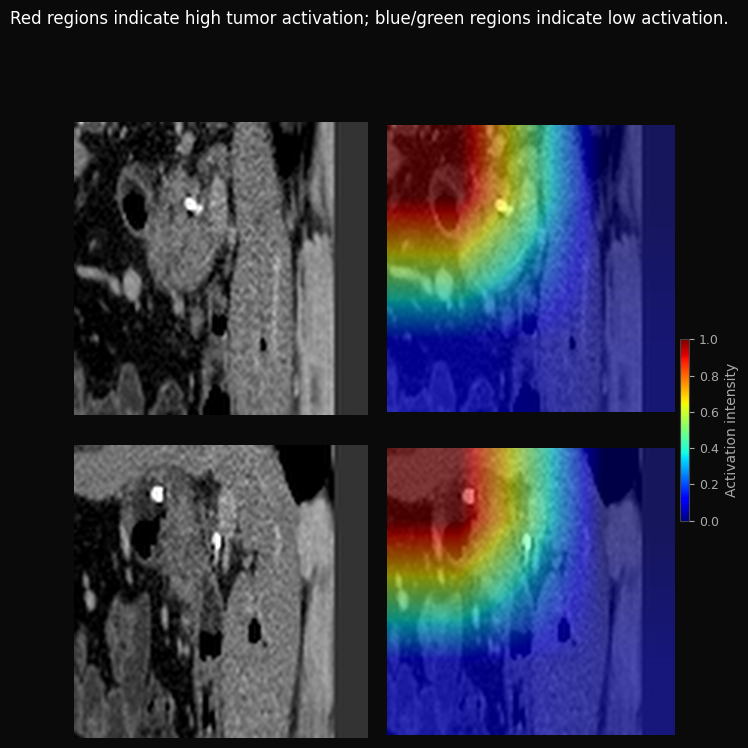

Saved → gradcam_sample_1.png


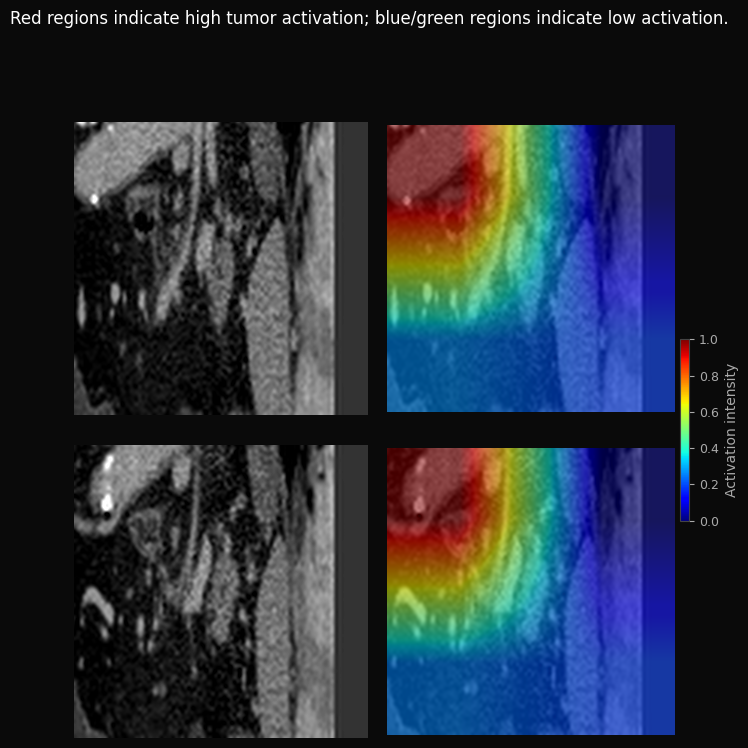

Saved → gradcam_sample_2.png


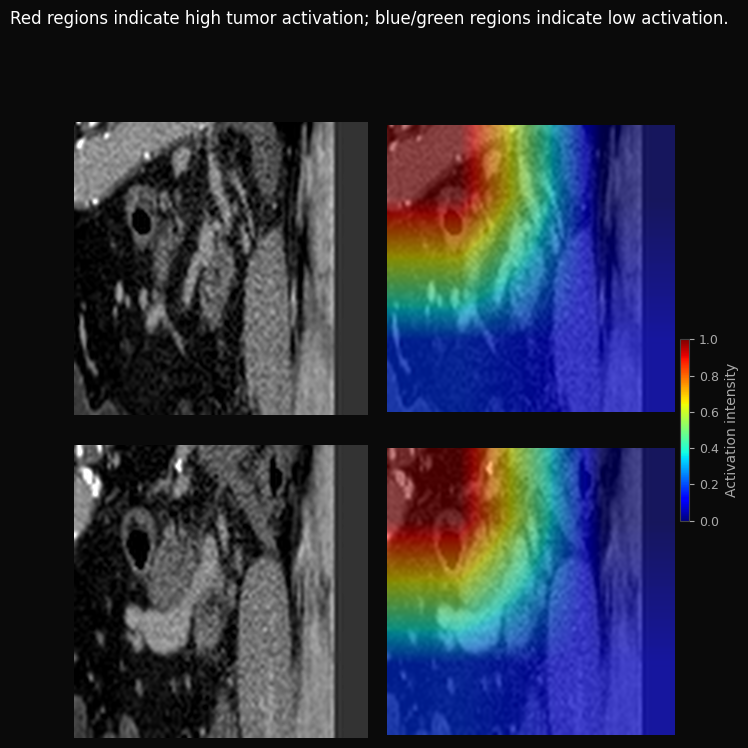

Saved → gradcam_sample_3.png


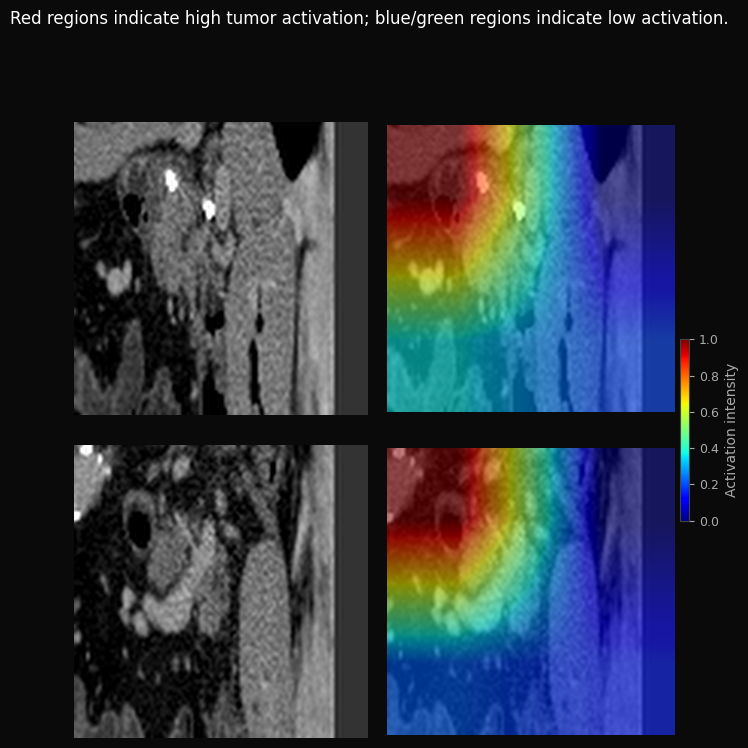

Saved → gradcam_sample_4.png


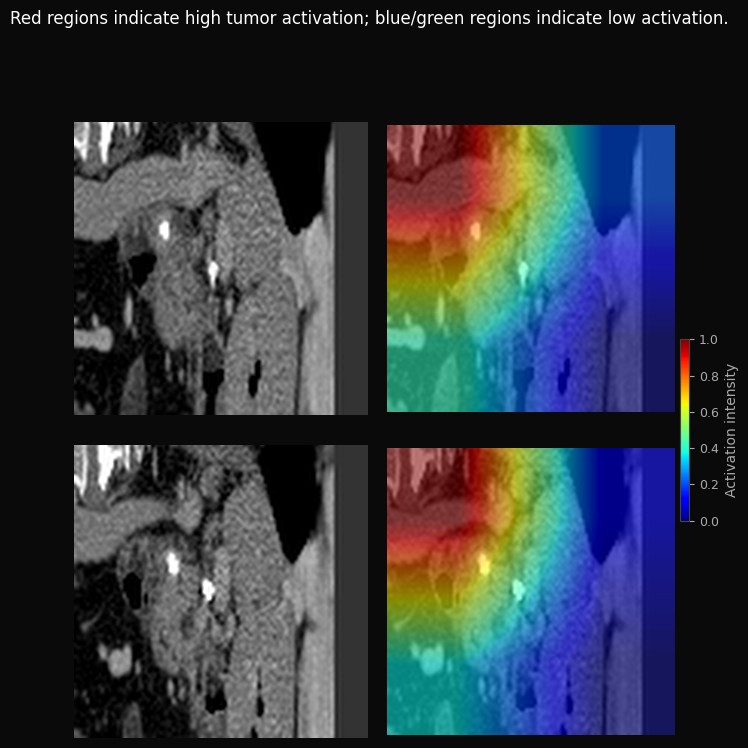

Saved → gradcam_sample_5.png


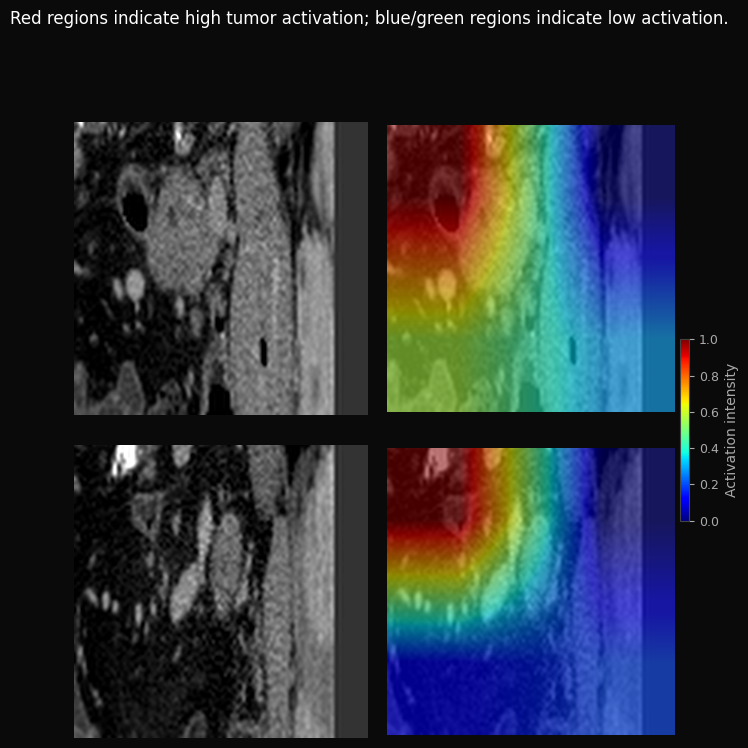

Saved → gradcam_sample_6.png

Done.


In [17]:
# ================= IMPORTS =================
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch.utils.data import DataLoader

# ================= GRAD-CAM++ =================
class GradCAMPlusPlus3D:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self._acts = None
        self._grads = None
        self.target_layer = model.backbone.layers4[-1]
        self._fwd_hook = self.target_layer.register_forward_hook(self._save_acts)
        self._bwd_hook = self.target_layer.register_full_backward_hook(self._save_grads)

    def _save_acts(self, module, inp, out):
        o = out[0] if isinstance(out, (list, tuple)) else out
        self._acts = o.detach()

    def _save_grads(self, module, grad_in, grad_out):
        g = grad_out[0] if isinstance(grad_out, (list, tuple)) else grad_out
        self._grads = g.detach()

    def generate(self, img_tensor, class_idx=1):
        self.model.eval()
        img = img_tensor.to(self.device).requires_grad_(True)
        logits = self.model(img)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        acts = self._acts.squeeze(0)    # (C, D, H, W)
        grads = self._grads.squeeze(0)  # (C, D, H, W)

        grads2 = grads ** 2
        grads3 = grads ** 3
        sum_acts = acts.sum(dim=(1,2,3), keepdim=True)
        denom = 2*grads2 + sum_acts*grads3 + 1e-7
        alpha = grads2 / denom
        weights = (F.relu(grads) * alpha).sum(dim=(1,2,3))

        cam = (weights[:, None, None, None] * acts).sum(dim=0)
        cam = F.relu(cam)
        cam = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),
            size=img_tensor.shape[2:],
            mode='trilinear',
            align_corners=False
        ).squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
        return cam

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# ================= VISUALISE FLEXIBLE NUMBER OF SLICES WITH CAPTION =================
def visualize_gradcam_slices(img_tensor, cam_vol, num_slices=2, sample_idx=0, save_path=None):
    img = np.clip(img_tensor.squeeze().cpu().numpy(), 0, 1)
    D = img.shape[0]

    # pick random slices (avoid edges)
    slices = np.random.choice(np.arange(10, D-10), size=num_slices, replace=False)

    fig, axes = plt.subplots(num_slices, 2, figsize=(8, 4*num_slices),
                             facecolor='#0a0a0a', gridspec_kw={'wspace':0.05,'hspace':0.1})

    if num_slices == 1:
        axes = axes.reshape(1, 2)

    for i, s_idx in enumerate(slices):
        img_slice = img[s_idx]
        cam_slice = cam_vol[s_idx]
        cam_slice = (cam_slice - cam_slice.min()) / (cam_slice.max() - cam_slice.min() + 1e-7)

        img_rgb = np.stack([img_slice]*3, axis=-1)
        heatmap = cm.get_cmap('jet')(cam_slice)[..., :3]
        blended = np.clip(0.45*img_rgb + 0.55*heatmap, 0, 1)

        axes[i,0].imshow(img_slice, cmap='gray', interpolation='lanczos', vmin=0, vmax=1)
        axes[i,0].axis('off')

        axes[i,1].imshow(blended, interpolation='lanczos')
        axes[i,1].axis('off')

    # colorbar
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0,1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[:,1], fraction=0.03, pad=0.02)
    cbar.set_label('Activation intensity', color='#aaaaaa', fontsize=10)
    cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa', fontsize=9)
    cbar.outline.set_edgecolor('#444444')

    # caption above figure
    fig.suptitle(
        f"Red regions indicate high tumor activation; blue/green regions indicate low activation.",
        color='white', fontsize=12, y=1.02
    )

    out_path = save_path or f"gradcam_sample_{sample_idx+1}.png"
    plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='#0a0a0a', pad_inches=0.15)
    plt.show()
    plt.close(fig)
    print(f"Saved → {out_path}")


# ================= RUN =================
gradcam = GradCAMPlusPlus3D(model, DEVICE)
explain_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
N_EXPLAIN = 6

for i, (img_t, _) in enumerate(explain_loader):
    if i >= N_EXPLAIN:
        break

    cam_vol = gradcam.generate(img_t, class_idx=1)

    # choose number of slices to display: 1, 2, 3, 4
    visualize_gradcam_slices(img_t, cam_vol, num_slices=2, sample_idx=i)

gradcam.remove_hooks()
print("\nDone.")